In [5]:
import jax
from jax import config
config.update("jax_enable_x64", True)
import warnings
warnings.filterwarnings("ignore", message="It appears that you're using a Mac with one of Apple's ARM-based processors")

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as c
from astropy.constants import G

from jax import numpy as jnp

from shone.chemistry import FastchemWrapper
from shone.opacity import Opacity
from shone.transmission import de_wit_seager_2013

'THESE HAPPEN OUTSIDE THE FUNCTION'
wavelengths = np.geomspace(0.81, 1.64, 100)
pressures = np.geomspace(1e-6, 1)  # [bar]
temperatures = 600 * (pressures / 0.1) ** 0.05  # [K]
molecules = ['H2O', 'CH4', 'CO2','CO','NH3']

binned_opacities = []
for mol in molecules:
    op = Opacity.load_species_from_name(mol)
    binned_opacities.append(
        op.get_binned_interpolator(wavelengths, temperatures, pressures) )
    
def dWS13_transmission_model(R_0 = (3.6 * u.R_earth).cgs.value,  # [cm]
                             T_atm = (600 * u.K).value, # K,
                             P_atm = (0.1 * u.bar).value, # bar
                             mmw = 20, #amu
                             mass = (11 * u.M_earth).cgs.value,  # [g]
                             R_star = (0.8 * u.R_sun).cgs.value,  # [cm]
                             plot=False,
    ):
       
    g = (c.G * mass / R_0**2).cgs.value  # [cm/s2]
    
    chem = FastchemWrapper(jnp.array([T_atm]), jnp.array([P_atm]))
    vmr = chem.vmr()
    weights_amu = chem.get_weights()
    vmr_indices = chem.get_column_index(species_name=molecules)
    
    molecular_opacities = []
    for i, mol in enumerate(molecules):
        this_mol_op = binned_opacities[i](jnp.array([T_atm]), jnp.array([P_atm]))
        molecular_opacities.append(this_mol_op)
    
    total_opacity = jnp.array(molecular_opacities).sum(axis=0)
    
    Rp_Rs = de_wit_seager_2013.transmission_radius(
        wavelengths, temperatures, pressures,
        g, R_0,
        total_opacity[None, ...],
        vmr, vmr_indices, weights_amu,
        rayleigh_scattering=True) / R_star

    if plot:
        # plot transmission spectrum:
        ax = plt.gca()
        ax.plot(wavelengths, Rp_Rs)
        
        # add labels for H2O features:
        label_height = Rp_Rs.max()
        
        water_peaks = [1.4]
        for peak in water_peaks:
            ax.annotate("H$_2$O", (peak, label_height), ha='center')
        
        ax.set(
            xlabel='Wavelength [µm]',
            ylabel='$R_{\\rm p}~/~R_{\\rm s}$',
            # ylim=(0.009, 0.014)
        )
    
    return Rp_Rs

In [9]:
from batman import TransitParams
import astropy.units as u
import numpy as np
from fleck import Star

planet = TransitParams()
planet.per = 88
planet.a = float((0.4*u.AU / u.R_sun).decompose())
planet.rp = 0.1
planet.w = 90
planet.ecc = 0
planet.inc = 90
planet.t0 = 0
planet.limb_dark = 'quadratic'
planet.u = [0,0]
planet.lam = 0

inc_stellar = 90 * u.deg
# spot_radii = np.array() 
# spot_lats = np.radians()
# spot_lons = np.radians([[0]])

times = np.linspace(-0.5,0.5, 100)

star = Star(spot_contrast=0.5, u_ld=planet.u, rotation_period=100, )
lc = star.light_curve(spot_lons, spot_lats, spot_radii,
                      inc_stellar, planet=planet, times=times)

star.plot(jnp.array([0,1,-1]), jnp.array([0.5,1.0,2.0]), jnp.array([0.05,0.2,0.1]), np.pi/2)

UnitTypeError: Longitude instances require units equivalent to 'rad', but no unit was given.

Array([0.04518784, 0.04518896, 0.04518576, 0.04518533, 0.04420298,
       0.04354909, 0.04356043, 0.04361579, 0.04365703, 0.04375474,
       0.04392011, 0.04404544, 0.04418362, 0.04445983, 0.04453494,
       0.0446123 , 0.04439539, 0.04421999, 0.04407465, 0.04427369,
       0.04458217, 0.04428476, 0.04411948, 0.04412792, 0.04417143,
       0.0441598 , 0.04424552, 0.04447691, 0.0444753 , 0.04457138,
       0.04458185, 0.04473385, 0.04493951, 0.0449373 , 0.04495526,
       0.04480546, 0.04469588, 0.04447947, 0.04441215, 0.04426053,
       0.04421762, 0.04416098, 0.04422852, 0.04415278, 0.04428377,
       0.04460909, 0.04479699, 0.04495332, 0.04467983, 0.04472376,
       0.04508474, 0.04492738, 0.04511483, 0.04499806, 0.04508599,
       0.04512378, 0.04509547, 0.04511151, 0.04500984, 0.04493457,
       0.04483466, 0.04464382, 0.04459661, 0.0443678 , 0.04468293,
       0.04479441, 0.04486624, 0.04492926, 0.04502258, 0.04497818,
       0.04506037, 0.0453317 , 0.04534022, 0.04534651, 0.04536

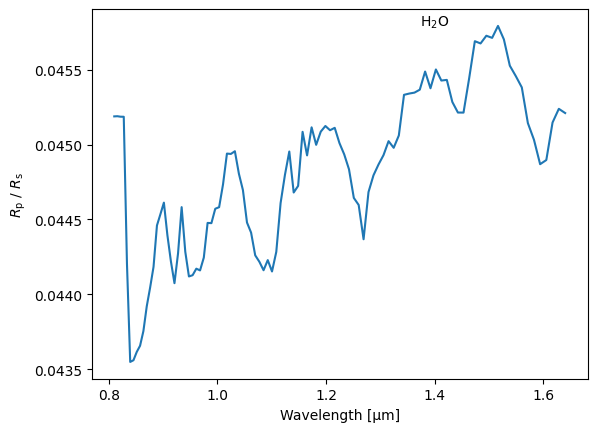

In [6]:
dWS13_transmission_model(plot=True)

In [ ]:
active_star = ActiveStar(
times=np.linspace(-0.25,0.25,300),
inclination=np.radians(85.0),  # stellar inc [rad]
T_eff=4100,
wavelength=Phot.wavelength.to_value(u.m), #use data wavelength array
phot=Phot.flux.value, #This is the model spectrum for the photosphere temp
P_rot=default_params['P_rot'])

for i in range(1, n_fixedspots + 1):
    # Generate random values within the parameter space for each spot
    lon = np.random.uniform(-np.pi,np.pi)
    lat = np.random.beta(2, 1)*(1.0 - 0.1) + 0.1
    rad = 0.01

    latspot = dict(
        lon=lon,  # Longitude [rad]
        lat=lat,  # Latitude [rad]
        rad=rad,  # Radius [R_star]
        spectrum=Cool.flux.value,  # Use provided spectrum
        temperature=default_params['T_spot'],  # Use provided temperature
    )
    # Add the spot to the active star
    active_star.add_spot(**latspot)
    
for i in range(1, n_spots + 1):
    # Generate random values within the parameter space for each spot
    lon = default_params[f"spot{i}_lon"]
    lat = default_params[f"spot{i}_lat"]
    rad = default_params[f"spot{i}_rad"]

    spot = dict(
        lon=lon,  # Longitude [rad]
        lat=lat,  # Latitude [rad]
        rad=rad,  # Radius [R_star]
        spectrum=Cool.flux.value,  # Use provided spectrum
        temperature=3100,  # Use provided temperature
    )
    # Add the spot to the active star
    active_star.add_spot(**spot)

'Plot the stellar surface'
active_star.plot_star(
    t0=0,
    rp=0.044,  # Exoplanet radius in units of stellar radii
    a=18,  # Planetary semi-major axis in units of stellar radii
    inclination=89.5,  # Planetary orbital inclination [radians]
    ecc=0.02 )
plt.savefig('../figs/starplot.png',dpi=250)
plt.show()
plt.clf()